<a href="https://colab.research.google.com/github/jealsab/mnist-training-pipeline-optimization/blob/main/mnist_pipeline_augmentation_and_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3.2 — TensorDatasets, CAE, and Augmentations
### MNIST Convolutional AutoEncoder with GPU-Resident Data

## Imports and Global Setup

In [ ]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision
from torchvision import datasets
from torchvision.transforms import v2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

BATCH_SIZE = 256
LATENT_DIM = 64
LR         = 1e-3
EPOCHS     = 10
VAL_SIZE   = 10000


Using device: cuda


---
## 3.2.1 — TensorDatasets for MNIST

### 3.2.1 (a) — Load MNIST and reserve 10,000 samples for validation

In [ ]:
# Pre-processing transforms (no augmentation)
pre_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

# Augmentation transforms (defined here, used later in 3.2.2)
augmentation_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(10, fill=0),
])

# Load raw MNIST (no transform yet — applied flexibly later)
mnist_train_full = datasets.MNIST(root='./data', train=True,  download=True, transform=None)
mnist_test_raw   = datasets.MNIST(root='./data', train=False, download=True, transform=None)

# Split: 50k train / 10k val
train_size = len(mnist_train_full) - VAL_SIZE          # 50 000
mnist_train_subset, mnist_val_subset = random_split(
    mnist_train_full, [train_size, VAL_SIZE],
    generator=torch.Generator().manual_seed(42)
)

print(f'Train size : {len(mnist_train_subset)}')
print(f'Val size   : {len(mnist_val_subset)}')
print(f'Test size  : {len(mnist_test_raw)}')


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.68MB/s]

Train size : 50000
Val size   : 10000
Test size  : 10000


### 3.2.1 (b) — Lazy DataLoader pipeline with on-the-fly preprocessing

In [ ]:
# Attach transforms to dataset copies for lazy loading
mnist_train_lazy = datasets.MNIST(root='./data', train=True,  download=False, transform=pre_transforms)
mnist_test_lazy  = datasets.MNIST(root='./data', train=False, download=False, transform=pre_transforms)

train_lazy_subset, val_lazy_subset = random_split(
    mnist_train_lazy, [train_size, VAL_SIZE],
    generator=torch.Generator().manual_seed(42)
)

train_loader_lazy = DataLoader(train_lazy_subset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True)
val_loader_lazy   = DataLoader(val_lazy_subset,   batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=2, pin_memory=True)
test_loader_lazy  = DataLoader(mnist_test_lazy,   batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=2, pin_memory=True)

# Inspect one mini-batch
imgs, labels = next(iter(train_loader_lazy))
print(f'Shape     : {imgs.shape}')                                    # (256, 1, 28, 28)
print(f'Dtype     : {imgs.dtype}')                                    # float32
print(f'Min/Max   : {imgs.min():.3f} / {imgs.max():.3f}')            # ~ [-1, 1]


Shape     : torch.Size([256, 1, 28, 28])
Dtype     : torch.float32
Min/Max   : -1.000 / 1.000


### 3.2.1 (c) — Convert splits to GPU-resident TensorDatasets

In [ ]:
def to_tensor_dataset(dataset, transform, device='cpu'):
    """Convert a Dataset or Subset to a TensorDataset with transforms pre-applied."""
    if isinstance(dataset, torch.utils.data.Subset):
        raw_data = dataset.dataset.data[dataset.indices]    # (N, 28, 28) uint8
        labels   = dataset.dataset.targets[dataset.indices]
    elif isinstance(dataset, torch.utils.data.Dataset):
        raw_data = dataset.data
        labels   = dataset.targets

    # Add channel dim → (N, 1, 28, 28) then apply transforms
    data_tensors = []
    for img in raw_data:
        img_tensor = transform(img.unsqueeze(0))            # (1, 28, 28)
        data_tensors.append(img_tensor)

    data_tensor   = torch.stack(data_tensors).to(device)
    labels_tensor = labels.to(device)
    return TensorDataset(data_tensor, labels_tensor)


print('Building GPU-resident TensorDatasets...')
t0 = time.time()
train_td = to_tensor_dataset(mnist_train_subset, pre_transforms, device=device)
val_td   = to_tensor_dataset(mnist_val_subset,   pre_transforms, device=device)
test_td  = to_tensor_dataset(mnist_test_raw,     pre_transforms, device=device)
print(f'Built in {time.time() - t0:.1f}s')

# Verification
x, y = train_td[0]
print(f'\nVerification:')
print(f'  Shape  : {x.shape}')                                        # (1, 28, 28)
print(f'  Dtype  : {x.dtype}')                                        # float32
print(f'  Device : {x.device}')                                       # cuda / cpu
print(f'  Min/Max: {train_td.tensors[0].min():.3f} / {train_td.tensors[0].max():.3f}')


Building GPU-resident TensorDatasets...
Built in 11.4s

Verification:
  Shape  : torch.Size([1, 28, 28])
  Dtype  : torch.float32
  Device : cuda:0
  Min/Max: -1.000 / 1.000


### 3.2.1 (d) — CAE architecture + train lazy vs TensorDataset, compare epoch times

In [ ]:
# ── CAE Architecture ──────────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),    # (32, 14, 14)
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),   # (64,  7,  7)
            nn.ReLU(),
            nn.Conv2d(64, latent_dim, 7),                 # (64,  1,  1)
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 64, 7),                                    # (64, 7, 7)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),    # (32,14,14)
            nn.ReLU(),
            nn.ConvTranspose2d(32,  1, 3, stride=2, padding=1, output_padding=1),    # ( 1,28,28)
            nn.Tanh(),
        )
    def forward(self, z):
        return self.net(z)

class CAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Shape sanity check
with torch.no_grad():
    dummy = torch.zeros(2, 1, 28, 28)
    out   = CAE()(dummy)
    print(f'Input : {dummy.shape}  →  Output : {out.shape}')


Input : torch.Size([2, 1, 28, 28])  →  Output : torch.Size([2, 1, 28, 28])


In [ ]:
# ── Generic CAE training loop ─────────────────────────────────────────────────
def train_cae(model, train_loader, val_loader, epochs, device, extra_transform=None):
    """Returns (train_losses, val_losses, epoch_times)."""
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    train_losses, val_losses, epoch_times = [], [], []

    for epoch in range(1, epochs + 1):
        t_start      = time.time()
        model.train()
        running_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            if extra_transform:
                imgs = extra_transform(imgs)
            optimizer.zero_grad()
            recon = model(imgs)
            loss  = criterion(recon, imgs)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                val_loss += criterion(model(imgs), imgs).item() * imgs.size(0)

        epoch_time = time.time() - t_start
        tl = running_loss / len(train_loader.dataset)
        vl = val_loss     / len(val_loader.dataset)
        train_losses.append(tl);  val_losses.append(vl);  epoch_times.append(epoch_time)
        print(f'Epoch {epoch:>2}/{epochs} | Train: {tl:.5f} | Val: {vl:.5f} | Time: {epoch_time:.2f}s')

    return train_losses, val_losses, epoch_times


In [ ]:
# ── Train with Lazy DataLoader ────────────────────────────────────────────────
print('=== Training with Lazy DataLoader (10 epochs) ===')
cae_lazy = CAE(LATENT_DIM)
tl_lazy, vl_lazy, times_lazy = train_cae(cae_lazy, train_loader_lazy, val_loader_lazy, EPOCHS, device)
print(f'\nAvg epoch time (Lazy): {np.mean(times_lazy):.2f}s')


=== Training with Lazy DataLoader (10 epochs) ===
Epoch  1/10 | Train: 0.28137 | Val: 0.14825 | Time: 17.28s
Epoch  2/10 | Train: 0.10124 | Val: 0.07218 | Time: 16.53s
Epoch  3/10 | Train: 0.05714 | Val: 0.04776 | Time: 16.45s
Epoch  4/10 | Train: 0.04285 | Val: 0.04049 | Time: 16.16s
Epoch  5/10 | Train: 0.03781 | Val: 0.03658 | Time: 17.13s
Epoch  6/10 | Train: 0.03494 | Val: 0.03477 | Time: 15.90s
Epoch  7/10 | Train: 0.03311 | Val: 0.03258 | Time: 16.31s
Epoch  8/10 | Train: 0.03144 | Val: 0.03098 | Time: 16.13s
Epoch  9/10 | Train: 0.03008 | Val: 0.02963 | Time: 17.36s
Epoch 10/10 | Train: 0.02917 | Val: 0.02893 | Time: 16.16s

Avg epoch time (Lazy): 16.54s


In [ ]:
# ── Train with GPU-Resident TensorDataset ────────────────────────────────────
train_loader_td = DataLoader(train_td, batch_size=BATCH_SIZE, shuffle=True)
val_loader_td   = DataLoader(val_td,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_td  = DataLoader(test_td,  batch_size=BATCH_SIZE, shuffle=False)

print('=== Training with GPU TensorDataset (10 epochs) ===')
cae_td = CAE(LATENT_DIM)
tl_td, vl_td, times_td = train_cae(cae_td, train_loader_td, val_loader_td, EPOCHS, device)
print(f'\nAvg epoch time (TensorDataset): {np.mean(times_td):.2f}s')
print(f'Speedup over Lazy            : {np.mean(times_lazy) / np.mean(times_td):.2f}x')


=== Training with GPU TensorDataset (10 epochs) ===
Epoch  1/10 | Train: 0.23414 | Val: 0.10354 | Time: 3.05s
Epoch  2/10 | Train: 0.06862 | Val: 0.05014 | Time: 2.75s
Epoch  3/10 | Train: 0.04226 | Val: 0.03730 | Time: 2.77s
Epoch  4/10 | Train: 0.03402 | Val: 0.03215 | Time: 3.04s
Epoch  5/10 | Train: 0.02931 | Val: 0.02818 | Time: 2.82s
Epoch  6/10 | Train: 0.02647 | Val: 0.02597 | Time: 2.80s
Epoch  7/10 | Train: 0.02474 | Val: 0.02447 | Time: 3.00s
Epoch  8/10 | Train: 0.02353 | Val: 0.02331 | Time: 2.91s
Epoch  9/10 | Train: 0.02261 | Val: 0.02278 | Time: 2.90s
Epoch 10/10 | Train: 0.02197 | Val: 0.02216 | Time: 2.98s

Avg epoch time (TensorDataset): 2.90s
Speedup over Lazy            : 5.70x


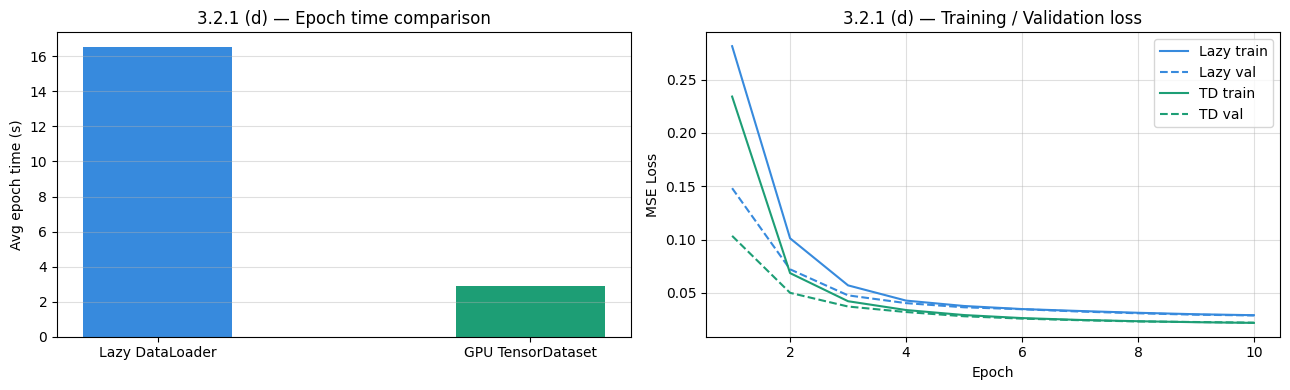

In [ ]:
# ── Epoch time comparison plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['Lazy DataLoader', 'GPU TensorDataset'],
            [np.mean(times_lazy), np.mean(times_td)],
            color=['#378ADD', '#1D9E75'], width=0.4)
axes[0].set_ylabel('Avg epoch time (s)')
axes[0].set_title('3.2.1 (d) — Epoch time comparison')
axes[0].grid(axis='y', alpha=0.4)

epochs_range = range(1, EPOCHS + 1)
axes[1].plot(epochs_range, tl_lazy, label='Lazy train',  color='#378ADD')
axes[1].plot(epochs_range, vl_lazy, label='Lazy val',    color='#378ADD', linestyle='--')
axes[1].plot(epochs_range, tl_td,   label='TD train',    color='#1D9E75')
axes[1].plot(epochs_range, vl_td,   label='TD val',      color='#1D9E75', linestyle='--')
axes[1].set_title('3.2.1 (d) — Training / Validation loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


---
## 3.2.2 — Adding Augmentations

### 3.2.2 (a) — Augmentations in the Lazy DataLoader pipeline

In [ ]:
# Combine pre-processing + augmentation for the lazy pipeline
aug_lazy_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(10, fill=0),
])

mnist_train_aug = datasets.MNIST(root='./data', train=True, download=False,
                                  transform=aug_lazy_transforms)
train_aug_subset, _ = random_split(
    mnist_train_aug, [train_size, VAL_SIZE],
    generator=torch.Generator().manual_seed(42)
)
# Validation uses clean (no-augmentation) transforms
train_loader_aug_lazy = DataLoader(train_aug_subset, batch_size=BATCH_SIZE, shuffle=True,
                                    num_workers=2, pin_memory=True)

print('=== 3.2.2 (a) Training CAE with Lazy Augmentation (10 epochs) ===')
cae_aug_lazy = CAE(LATENT_DIM)
tl_aug_lazy, vl_aug_lazy, times_aug_lazy = train_cae(
    cae_aug_lazy, train_loader_aug_lazy, val_loader_lazy, EPOCHS, device
)


=== 3.2.2 (a) Training CAE with Lazy Augmentation (10 epochs) ===
Epoch  1/10 | Train: 0.30341 | Val: 0.17744 | Time: 37.66s
Epoch  2/10 | Train: 0.11370 | Val: 0.07065 | Time: 37.01s
Epoch  3/10 | Train: 0.06564 | Val: 0.05234 | Time: 36.48s
Epoch  4/10 | Train: 0.05416 | Val: 0.04649 | Time: 37.13s
Epoch  5/10 | Train: 0.04943 | Val: 0.04231 | Time: 37.67s
Epoch  6/10 | Train: 0.04664 | Val: 0.04035 | Time: 37.42s
Epoch  7/10 | Train: 0.04377 | Val: 0.03789 | Time: 36.26s
Epoch  8/10 | Train: 0.04181 | Val: 0.03504 | Time: 37.20s
Epoch  9/10 | Train: 0.03984 | Val: 0.03394 | Time: 37.47s
Epoch 10/10 | Train: 0.03857 | Val: 0.03332 | Time: 36.98s


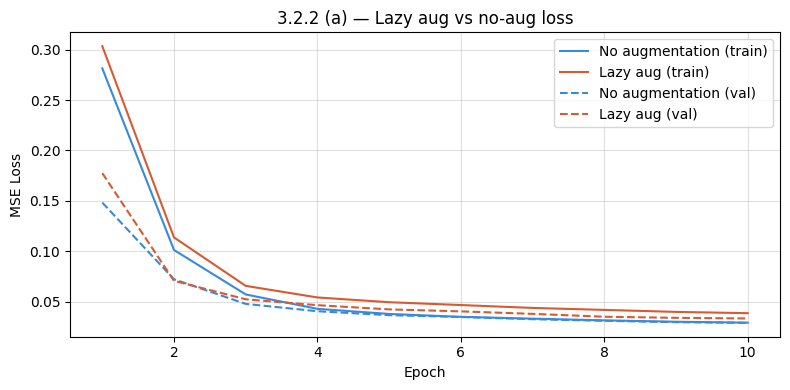

In [ ]:
# ── Compare training loss: no-aug vs lazy-aug ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ep = range(1, EPOCHS + 1)
ax.plot(ep, tl_lazy,     label='No augmentation (train)', color='#378ADD')
ax.plot(ep, tl_aug_lazy, label='Lazy aug (train)',         color='#D85A30')
ax.plot(ep, vl_lazy,     label='No augmentation (val)',   color='#378ADD', linestyle='--')
ax.plot(ep, vl_aug_lazy, label='Lazy aug (val)',           color='#D85A30', linestyle='--')
ax.set_title('3.2.2 (a) — Lazy aug vs no-aug loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


### 3.2.2 (b) — Augmentations via AugmentedTensorDataset

In [ ]:
class AugmentedTensorDataset(TensorDataset):
    """TensorDataset wrapper that applies per-sample transforms on __getitem__."""
    def __init__(self, tensor_dataset, transforms=None):
        self.tensor_dataset = tensor_dataset
        self.transforms     = transforms

    def __len__(self):
        return len(self.tensor_dataset)

    def __getitem__(self, idx):
        data, label = self.tensor_dataset[idx]
        if self.transforms:
            data = self.transforms(data)
        return data, label


aug_td_train          = AugmentedTensorDataset(train_td, transforms=augmentation_transforms)
train_loader_aug_td   = DataLoader(aug_td_train, batch_size=BATCH_SIZE, shuffle=True)

print('=== 3.2.2 (b) Training CAE with AugmentedTensorDataset (10 epochs) ===')
cae_aug_td = CAE(LATENT_DIM)
tl_aug_td, vl_aug_td, times_aug_td = train_cae(
    cae_aug_td, train_loader_aug_td, val_loader_td, EPOCHS, device
)


=== 3.2.2 (b) Training CAE with AugmentedTensorDataset (10 epochs) ===
Epoch  1/10 | Train: 0.32010 | Val: 0.15612 | Time: 38.15s
Epoch  2/10 | Train: 0.10836 | Val: 0.07048 | Time: 37.79s
Epoch  3/10 | Train: 0.06593 | Val: 0.05178 | Time: 39.46s
Epoch  4/10 | Train: 0.05282 | Val: 0.04314 | Time: 39.18s
Epoch  5/10 | Train: 0.04747 | Val: 0.03866 | Time: 39.07s
Epoch  6/10 | Train: 0.04437 | Val: 0.03682 | Time: 38.87s
Epoch  7/10 | Train: 0.04245 | Val: 0.03471 | Time: 39.46s
Epoch  8/10 | Train: 0.04114 | Val: 0.03409 | Time: 38.36s
Epoch  9/10 | Train: 0.03974 | Val: 0.03276 | Time: 38.04s
Epoch 10/10 | Train: 0.03877 | Val: 0.03182 | Time: 38.36s


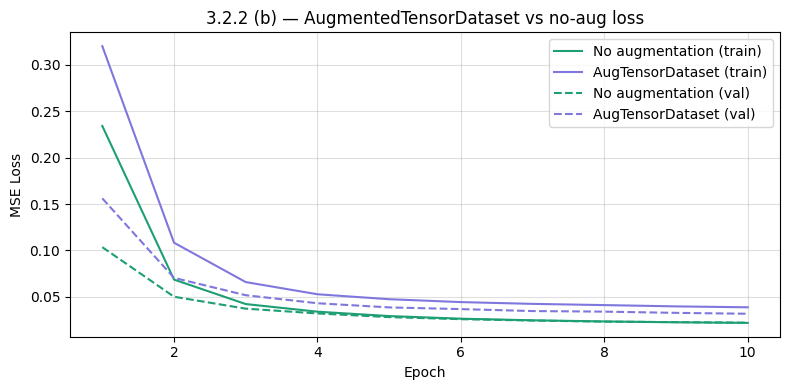

In [ ]:
# ── Compare training loss: TensorDataset no-aug vs aug ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ep = range(1, EPOCHS + 1)
ax.plot(ep, tl_td,     label='No augmentation (train)', color='#1D9E75')
ax.plot(ep, tl_aug_td, label='AugTensorDataset (train)', color='#7F77DD')
ax.plot(ep, vl_td,     label='No augmentation (val)',   color='#1D9E75', linestyle='--')
ax.plot(ep, vl_aug_td, label='AugTensorDataset (val)',   color='#7F77DD', linestyle='--')
ax.set_title('3.2.2 (b) — AugmentedTensorDataset vs no-aug loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


### 3.2.2 (c) — GPU Batch Augmentation (100 epochs) + full comparison

In [ ]:
# Batch augmentation transforms run directly on GPU tensors inside the training loop
batch_aug = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(10, fill=0),
])

print('=== 3.2.2 (c) Training CAE with GPU Batch Augmentations (100 epochs) ===')
cae_batch_aug = CAE(LATENT_DIM)
tl_batch, vl_batch, times_batch = train_cae(
    cae_batch_aug, train_loader_td, val_loader_td,
    epochs=100, device=device,
    extra_transform=batch_aug
)
print(f'\nAvg epoch time (batch aug 100ep): {np.mean(times_batch):.2f}s')


=== 3.2.2 (c) Training CAE with GPU Batch Augmentations (100 epochs) ===
Epoch  1/100 | Train: 0.32025 | Val: 0.23912 | Time: 3.13s
Epoch  2/100 | Train: 0.16328 | Val: 0.09735 | Time: 3.05s
Epoch  3/100 | Train: 0.09728 | Val: 0.06948 | Time: 3.14s
Epoch  4/100 | Train: 0.06688 | Val: 0.07969 | Time: 3.00s
Epoch  5/100 | Train: 0.06098 | Val: 0.05174 | Time: 3.11s
Epoch  6/100 | Train: 0.05380 | Val: 0.05620 | Time: 3.09s
Epoch  7/100 | Train: 0.05068 | Val: 0.04149 | Time: 3.03s
Epoch  8/100 | Train: 0.04753 | Val: 0.03962 | Time: 3.04s
Epoch  9/100 | Train: 0.04606 | Val: 0.03438 | Time: 3.17s
Epoch 10/100 | Train: 0.04452 | Val: 0.03512 | Time: 3.26s
Epoch 11/100 | Train: 0.04312 | Val: 0.03674 | Time: 3.02s
Epoch 12/100 | Train: 0.04291 | Val: 0.03370 | Time: 3.01s
Epoch 13/100 | Train: 0.04173 | Val: 0.03176 | Time: 3.08s
Epoch 14/100 | Train: 0.04003 | Val: 0.03257 | Time: 3.04s
Epoch 15/100 | Train: 0.04253 | Val: 0.03109 | Time: 2.97s
Epoch 16/100 | Train: 0.03790 | Val: 0.029

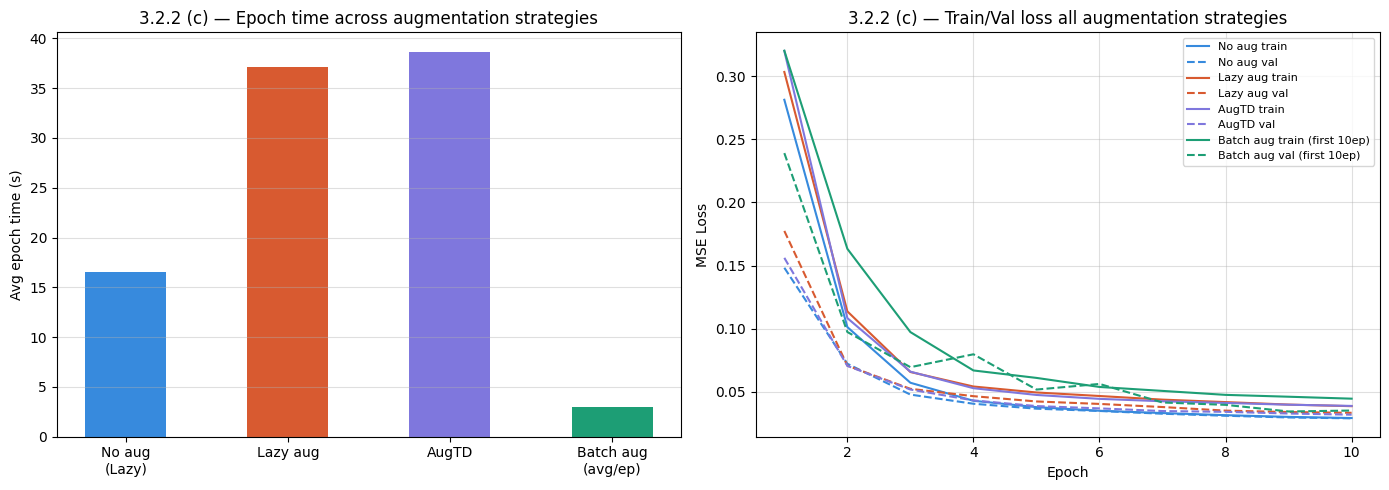

In [ ]:
# ── Full augmentation comparison: epoch times ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Epoch time bar chart (all three augmentation strategies, 10-epoch runs)
labels_bar = ['No aug\n(Lazy)', 'Lazy aug', 'AugTD', 'Batch aug\n(avg/ep)']
times_bar  = [np.mean(times_lazy), np.mean(times_aug_lazy),
              np.mean(times_aug_td), np.mean(times_batch)]
colors_bar = ['#378ADD', '#D85A30', '#7F77DD', '#1D9E75']
axes[0].bar(labels_bar, times_bar, color=colors_bar, width=0.5)
axes[0].set_ylabel('Avg epoch time (s)')
axes[0].set_title('3.2.2 (c) — Epoch time across augmentation strategies')
axes[0].grid(axis='y', alpha=0.4)

# Training & validation loss for all three augmentation modes (10-epoch window)
ep10 = range(1, EPOCHS + 1)
axes[1].plot(ep10, tl_lazy,     label='No aug train',    color='#378ADD')
axes[1].plot(ep10, vl_lazy,     label='No aug val',      color='#378ADD', linestyle='--')
axes[1].plot(ep10, tl_aug_lazy, label='Lazy aug train',  color='#D85A30')
axes[1].plot(ep10, vl_aug_lazy, label='Lazy aug val',    color='#D85A30', linestyle='--')
axes[1].plot(ep10, tl_aug_td,   label='AugTD train',     color='#7F77DD')
axes[1].plot(ep10, vl_aug_td,   label='AugTD val',       color='#7F77DD', linestyle='--')
axes[1].plot(range(1, 11), tl_batch[:10], label='Batch aug train (first 10ep)', color='#1D9E75')
axes[1].plot(range(1, 11), vl_batch[:10], label='Batch aug val (first 10ep)',   color='#1D9E75', linestyle='--')
axes[1].set_title('3.2.2 (c) — Train/Val loss all augmentation strategies')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()


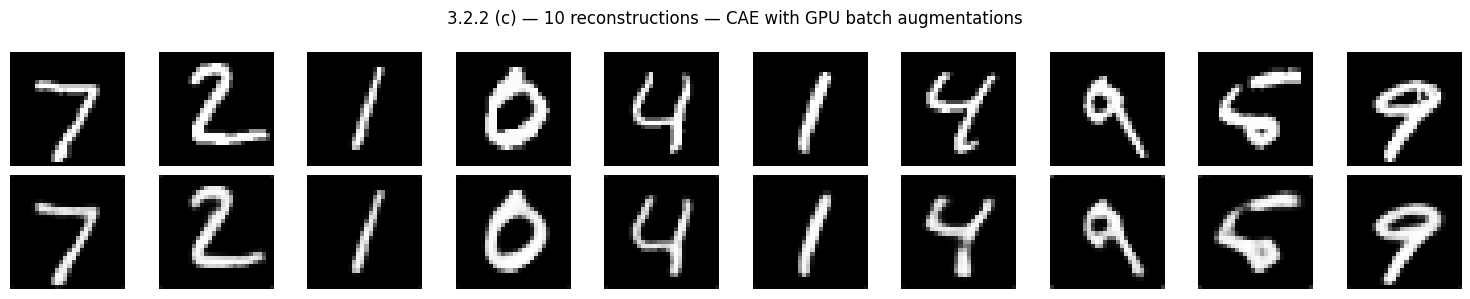

In [ ]:
# ── Plot 10 reconstructions of CAE trained with batch augmentations ───────────
def show_reconstructions(model, loader, device, n=10, title='Reconstructions'):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs    = imgs[:n].to(device)
    with torch.no_grad():
        recons = model(imgs)
    imgs   = imgs.cpu().numpy()
    recons = recons.cpu().numpy()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(imgs[i, 0],   cmap='gray', vmin=-1, vmax=1)
        axes[1, i].imshow(recons[i, 0], cmap='gray', vmin=-1, vmax=1)
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Original',      fontsize=9)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
    fig.suptitle(f'3.2.2 (c) — {title}', fontsize=12)
    plt.tight_layout(); plt.show()

show_reconstructions(cae_batch_aug, test_loader_td, device,
                     title='10 reconstructions — CAE with GPU batch augmentations')


---
## 3.2.3 — Pre-Trained Encoder for Classification

### Architecture: EncoderClassifier + training helpers

In [ ]:
class EncoderClassifier(nn.Module):
    def __init__(self, encoder, num_classes=10, freeze_encoder=True):
        super().__init__()
        self.encoder = encoder
        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
        # Encoder outputs (B, 64, 1, 1) → flatten → Linear
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(LATENT_DIM, num_classes)
        )
    def forward(self, x):
        z = self.encoder(x)         # (B, 64, 1, 1)
        return self.classifier(z)


def train_classifier(model, train_loader, val_loader, epochs, device, lr=LR):
    model     = model.to(device)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                val_loss += criterion(model(imgs), labels).item() * imgs.size(0)

        tl = running_loss / len(train_loader.dataset)
        vl = val_loss     / len(val_loader.dataset)
        train_losses.append(tl); val_losses.append(vl)
        if epoch % 10 == 0:
            print(f'Epoch {epoch:>3}/{epochs} | Train: {tl:.4f} | Val: {vl:.4f}')

    return train_losses, val_losses


def evaluate_accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds    = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total


CLF_EPOCHS = 50


### 3.2.3 (a) — Frozen pretrained encoder: train classification head only

In [ ]:
encoder_frozen = copy.deepcopy(cae_batch_aug.encoder.to('cpu'))
clf_frozen     = EncoderClassifier(encoder_frozen, freeze_encoder=True)

print('=== 3.2.3 (a) Frozen Pretrained Encoder ===')
tl_frozen, vl_frozen = train_classifier(
    clf_frozen, train_loader_td, val_loader_td, CLF_EPOCHS, device
)
acc_frozen = evaluate_accuracy(clf_frozen, test_loader_td, device)
print(f'\nTest Accuracy (Frozen): {acc_frozen * 100:.2f}%')


=== 3.2.3 (a) Frozen Pretrained Encoder ===
Epoch  10/50 | Train: 0.2899 | Val: 0.2965
Epoch  20/50 | Train: 0.2636 | Val: 0.2755
Epoch  30/50 | Train: 0.2584 | Val: 0.2712
Epoch  40/50 | Train: 0.2556 | Val: 0.2702
Epoch  50/50 | Train: 0.2548 | Val: 0.2707

Test Accuracy (Frozen): 93.07%


### 3.2.3 (b) — Fine-tune the full pretrained model with smaller lr

In [ ]:
encoder_finetune = copy.deepcopy(cae_batch_aug.encoder.to('cpu'))
clf_finetune     = EncoderClassifier(encoder_finetune, freeze_encoder=False)

print('=== 3.2.3 (b) Fine-Tuned Pretrained Encoder ===')
tl_finetune, vl_finetune = train_classifier(
    clf_finetune, train_loader_td, val_loader_td, CLF_EPOCHS, device, lr=1e-4
)
acc_finetune = evaluate_accuracy(clf_finetune, test_loader_td, device)
print(f'\nTest Accuracy (Fine-tuned): {acc_finetune * 100:.2f}%')


=== 3.2.3 (b) Fine-Tuned Pretrained Encoder ===
Epoch  10/50 | Train: 0.1344 | Val: 0.1420
Epoch  20/50 | Train: 0.0685 | Val: 0.0828
Epoch  30/50 | Train: 0.0451 | Val: 0.0676
Epoch  40/50 | Train: 0.0324 | Val: 0.0588
Epoch  50/50 | Train: 0.0240 | Val: 0.0544

Test Accuracy (Fine-tuned): 98.71%


### 3.2.3 (c) — Train from scratch with randomly initialized encoder

In [ ]:
encoder_scratch = Encoder(LATENT_DIM)          # random weights — no pretraining
clf_scratch     = EncoderClassifier(encoder_scratch, freeze_encoder=False)

print('=== 3.2.3 (c) Training From Scratch ===')
tl_scratch, vl_scratch = train_classifier(
    clf_scratch, train_loader_td, val_loader_td, CLF_EPOCHS, device
)
acc_scratch = evaluate_accuracy(clf_scratch, test_loader_td, device)
print(f'\nTest Accuracy (Scratch): {acc_scratch * 100:.2f}%')


=== 3.2.3 (c) Training From Scratch ===
Epoch  10/50 | Train: 0.0210 | Val: 0.0589
Epoch  20/50 | Train: 0.0060 | Val: 0.0688
Epoch  30/50 | Train: 0.0001 | Val: 0.0737
Epoch  40/50 | Train: 0.0000 | Val: 0.0825
Epoch  50/50 | Train: 0.0000 | Val: 0.0912

Test Accuracy (Scratch): 98.73%


### 3.2.3 (d) — Loss curves for all three settings + final comparison table

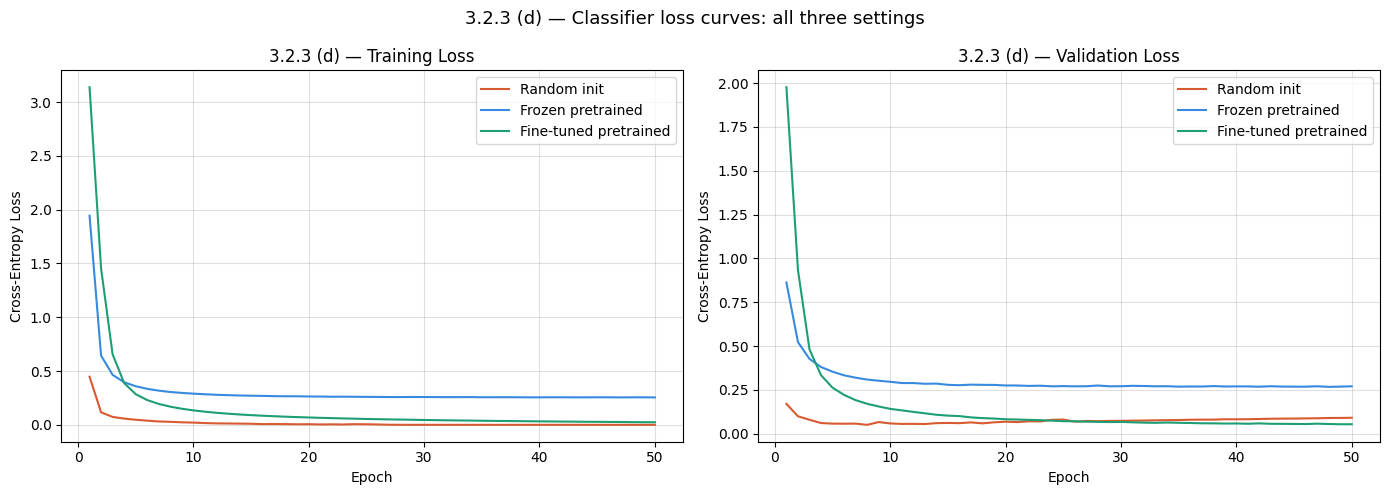

In [ ]:
# ── Loss curves ───────────────────────────────────────────────────────────────
epochs_range = range(1, CLF_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
axes[0].plot(epochs_range, tl_scratch,  label='Random init',          color='#D85A30')
axes[0].plot(epochs_range, tl_frozen,   label='Frozen pretrained',     color='#378ADD')
axes[0].plot(epochs_range, tl_finetune, label='Fine-tuned pretrained', color='#1D9E75')
axes[0].set_title('3.2.3 (d) — Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Validation loss
axes[1].plot(epochs_range, vl_scratch,  label='Random init',          color='#D85A30')
axes[1].plot(epochs_range, vl_frozen,   label='Frozen pretrained',     color='#378ADD')
axes[1].plot(epochs_range, vl_finetune, label='Fine-tuned pretrained', color='#1D9E75')
axes[1].set_title('3.2.3 (d) — Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('3.2.3 (d) — Classifier loss curves: all three settings', fontsize=13)
plt.tight_layout(); plt.show()


In [ ]:
# ── Final comparison table ────────────────────────────────────────────────────
print('\n' + '=' * 55)
print(f'{"Setting":<30} {"Test Accuracy":>15}')
print('=' * 55)
print(f'{"Random initialization":<30} {acc_scratch  * 100:>14.2f}%')
print(f'{"Frozen pretrained encoder":<30} {acc_frozen   * 100:>14.2f}%')
print(f'{"Fine-tuned pretrained encoder":<30} {acc_finetune * 100:>14.2f}%')
print('=' * 55)



Setting                          Test Accuracy
Random initialization                   98.73%
Frozen pretrained encoder               93.07%
Fine-tuned pretrained encoder           98.71%
